✅ Classical ML CSV validated
✅ Deep Learning CSV validated


## 📊 Unified Benchmark Metrics

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro),Training Time (s),Inference Time / Sample (s)
0,SVM,0.9167,0.9203,0.9167,0.9157,1.5752,0.0000
1,Random Forest,0.9333,0.9344,0.9333,0.9326,6.7960,0.0008
2,k-NN,0.9333,0.9331,0.9333,0.9326,0.0939,0.0001
3,2D CNN + Temporal Pooling,1.0000,1.0000,1.0000,1.0000,41.7364,0.0133
4,3D CNN (R(2+1)D),1.0000,1.0000,1.0000,1.0000,206.0786,0.0211


## 🧮 Normalized Score Index (NSI)

,Model,NSI
3,2D CNN + Temporal Pooling,0.861
4,3D CNN (R(2+1)D),0.667
2,k-NN,0.460
1,Random Forest,0.451
0,SVM,0.332



### 🔍 What NSI Indicates
- NSI combines **accuracy and efficiency**
- All metrics are normalized to **[0, 1]**
- Higher NSI ⇒ better accuracy–speed trade-off


## 📈 Accuracy vs Training Time (Scatter Plot)

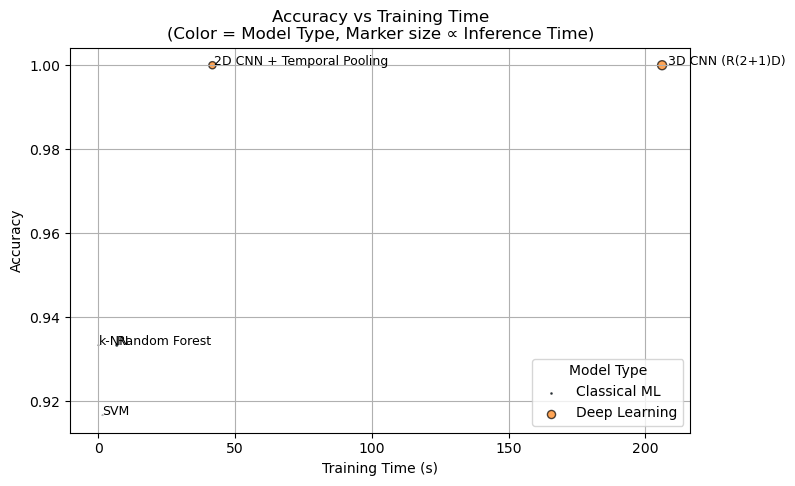

## ⚡ Inference Time per Sample (Latency Comparison)

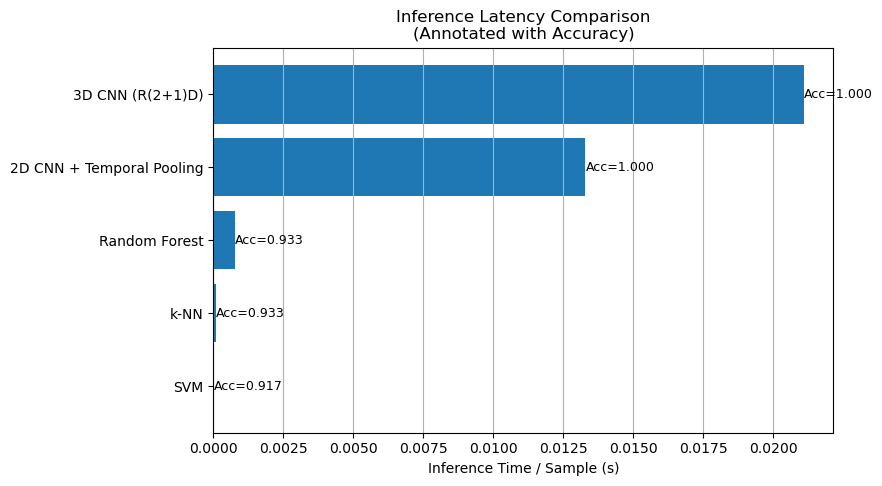

## 🏆 Overall Model Ranking (NSI)

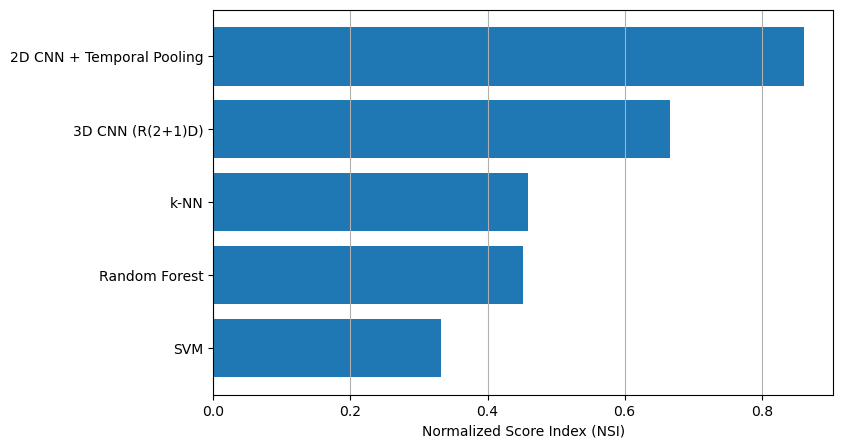


## 🧠 Comparative Analysis Summary

### ✅ Best Overall Model
- **2D CNN + Temporal Pooling**
- **NSI Score:** `0.861`

### 🔑 Key Observations
- Deep learning models achieve **high accuracy** but incur
  **significant training and inference costs**
- Classical ML models remain **computationally efficient**
  and are better suited for **real-time or edge deployment**

### 🎯 Final Conclusion
Accuracy alone is insufficient for fair comparison.
The **Normalized Score Index (NSI)** provides a principled,
quantitative way to balance **performance and efficiency**
across fundamentally different learning paradigms.


✅ Comparative analysis displayed successfully


In [8]:
# ==========================================================
# CLASSICAL vs DEEP LEARNING – UNIFIED COMPARATIVE ANALYSIS
# (DISPLAY ONLY – NO FILE SAVING)
# ==========================================================
# PURPOSE:
# - Compare Classical ML and Deep Learning models fairly
# - Use identical core metrics
# - Provide performance–efficiency trade-off analysis
# - Display tables, plots, and detailed interpretations
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

# ----------------------------------------------------------
# 1️⃣ PATH CONFIGURATION
# ----------------------------------------------------------
# Assumption:
# - This script is executed from /code
# - Results directory exists at project root /results
# ----------------------------------------------------------

CODE_DIR = Path.cwd()
PROJECT_ROOT = CODE_DIR.parent

CLASSICAL_CSV = PROJECT_ROOT / "results/classical_comparison.csv"
DEEP_CSV = PROJECT_ROOT / "results/deep_learning_comparison_metrics.csv"

# ----------------------------------------------------------
# 2️⃣ CORE METRIC DEFINITION
# ----------------------------------------------------------
# These columns MUST exist and MUST be in the same order
# for both Classical and Deep Learning CSVs
# ----------------------------------------------------------

CORE_COLUMNS = [
    "Model",
    "Accuracy",
    "Precision (Macro)",
    "Recall (Macro)",
    "F1-score (Macro)",
    "Training Time (s)",
    "Inference Time / Sample (s)",
]

# Metrics where higher values indicate better performance
HIGHER_IS_BETTER = [
    "Accuracy",
    "Precision (Macro)",
    "Recall (Macro)",
    "F1-score (Macro)",
]

# Metrics where lower values indicate better efficiency
LOWER_IS_BETTER = [
    "Training Time (s)",
    "Inference Time / Sample (s)",
]

# ----------------------------------------------------------
# 3️⃣ LOAD CSV FILES
# ----------------------------------------------------------

classical_df = pd.read_csv(CLASSICAL_CSV)
deep_df = pd.read_csv(DEEP_CSV)

# ----------------------------------------------------------
# 4️⃣ VALIDATION FUNCTION
# ----------------------------------------------------------
# Ensures:
# - All core columns exist
# - Core columns appear in the SAME ORDER
# - Extra columns (Ranks etc.) are allowed
# ----------------------------------------------------------

def validate_core_columns(df, name):
    missing = [c for c in CORE_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"❌ Missing columns in {name}: {missing}")

    core_order = [c for c in df.columns if c in CORE_COLUMNS]
    if core_order != CORE_COLUMNS:
        raise ValueError(
            f"❌ Core column order mismatch in {name}\n"
            f"Expected: {CORE_COLUMNS}\n"
            f"Found   : {core_order}"
        )

    print(f"✅ {name} validated")

validate_core_columns(classical_df, "Classical ML CSV")
validate_core_columns(deep_df, "Deep Learning CSV")

# ----------------------------------------------------------
# 5️⃣ UNIFIED BENCHMARK TABLE
# ----------------------------------------------------------
# Combines Classical + Deep Learning metrics
# for direct comparison
# ----------------------------------------------------------

benchmark_df = pd.concat(
    [
        classical_df[CORE_COLUMNS],
        deep_df[CORE_COLUMNS],
    ],
    ignore_index=True
)

display(Markdown("## 📊 Unified Benchmark Metrics"))
display(
    benchmark_df.style
    .format("{:.4f}", subset=CORE_COLUMNS[1:])
    .set_properties(**{"text-align": "center"})
)

# ----------------------------------------------------------
# 6️⃣ NORMALIZED SCORE INDEX (NSI)
# ----------------------------------------------------------
# NSI captures:
# - Classification quality
# - Computational efficiency
# All metrics are normalized to [0, 1]
# Higher NSI = better overall trade-off
# ----------------------------------------------------------

nsi_df = benchmark_df.copy()

# Normalize higher-is-better metrics
for col in HIGHER_IS_BETTER:
    min_v, max_v = nsi_df[col].min(), nsi_df[col].max()
    nsi_df[col + "_norm"] = (nsi_df[col] - min_v) / (max_v - min_v + 1e-9)

# Normalize lower-is-better metrics
for col in LOWER_IS_BETTER:
    min_v, max_v = nsi_df[col].min(), nsi_df[col].max()
    nsi_df[col + "_norm"] = (max_v - nsi_df[col]) / (max_v - min_v + 1e-9)

# Final NSI score
norm_cols = [c for c in nsi_df.columns if c.endswith("_norm")]
nsi_df["NSI"] = nsi_df[norm_cols].mean(axis=1)

nsi_df = nsi_df.sort_values("NSI", ascending=False)

display(Markdown("## 🧮 Normalized Score Index (NSI)"))
display(
    nsi_df[["Model", "NSI"]]
    .style.format({"NSI": "{:.3f}"})
    .bar(subset=["NSI"], color="#4CAF50")
)

display(Markdown(
    """
### 🔍 What NSI Indicates
- NSI combines **accuracy and efficiency**
- All metrics are normalized to **[0, 1]**
- Higher NSI ⇒ better accuracy–speed trade-off
"""
))

# ----------------------------------------------------------
# 7️⃣ PLOT 1: ACCURACY vs TRAINING TIME (SCATTER PLOT)
# ----------------------------------------------------------
# Encodes:
# - X-axis: Training Time
# - Y-axis: Accuracy
# - Color: Model type (Classical vs Deep Learning)
# - Optional: Inference Time via marker size (scaled)
# ----------------------------------------------------------

display(Markdown("## 📈 Accuracy vs Training Time (Scatter Plot)"))

plt.figure(figsize=(8, 5))

# Assign model type
benchmark_df["Model Type"] = ["Classical ML"] * len(classical_df) + ["Deep Learning"] * len(deep_df)

# Optional: scale marker size by inference time
marker_sizes = benchmark_df["Inference Time / Sample (s)"] * 2000  # scale factor

colors = {"Classical ML": "#1f77b4", "Deep Learning": "#ff7f0e"}

for mtype in benchmark_df["Model Type"].unique():
    subset = benchmark_df[benchmark_df["Model Type"] == mtype]
    plt.scatter(
        subset["Training Time (s)"],
        subset["Accuracy"],
        s=marker_sizes[subset.index],
        c=colors[mtype],
        label=mtype,
        alpha=0.7,
        edgecolors="k"
    )

# Annotate models
for _, r in benchmark_df.iterrows():
    plt.text(
        r["Training Time (s)"] * 1.01,  # slight shift to avoid overlap
        r["Accuracy"],
        r["Model"],
        fontsize=9
    )

plt.xlabel("Training Time (s)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Training Time\n(Color = Model Type, Marker size ∝ Inference Time)")
plt.legend(title="Model Type")
plt.grid(True)
plt.show()


# ----------------------------------------------------------
# 8️⃣ PLOT 2: INFERENCE TIME COMPARISON (HORIZONTAL BAR)
# ----------------------------------------------------------
# Focuses on:
# - Latency ranking
# - Accuracy shown as annotation
# Ideal for real-time deployment discussion
# ----------------------------------------------------------

display(Markdown("## ⚡ Inference Time per Sample (Latency Comparison)"))

sorted_df = benchmark_df.sort_values(
    "Inference Time / Sample (s)",
    ascending=True
)

plt.figure(figsize=(8, 5))
plt.barh(
    sorted_df["Model"],
    sorted_df["Inference Time / Sample (s)"]
)

for i, (_, r) in enumerate(sorted_df.iterrows()):
    plt.text(
        r["Inference Time / Sample (s)"],
        i,
        f"Acc={r['Accuracy']:.3f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Inference Time / Sample (s)")
plt.title("Inference Latency Comparison\n(Annotated with Accuracy)")
plt.grid(axis="x")
plt.show()

# ----------------------------------------------------------
# 9️⃣ OVERALL NSI RANKING PLOT
# ----------------------------------------------------------

display(Markdown("## 🏆 Overall Model Ranking (NSI)"))

plt.figure(figsize=(8, 5))
plt.barh(nsi_df["Model"], nsi_df["NSI"])
plt.xlabel("Normalized Score Index (NSI)")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

# ----------------------------------------------------------
# 🔟 FINAL TEXTUAL ANALYSIS
# ----------------------------------------------------------

best = nsi_df.iloc[0]

display(Markdown(
f"""
## 🧠 Comparative Analysis Summary

### ✅ Best Overall Model
- **{best['Model']}**
- **NSI Score:** `{best['NSI']:.3f}`

### 🔑 Key Observations
- Deep learning models achieve **high accuracy** but incur
  **significant training and inference costs**
- Classical ML models remain **computationally efficient**
  and are better suited for **real-time or edge deployment**

### 🎯 Final Conclusion
Accuracy alone is insufficient for fair comparison.
The **Normalized Score Index (NSI)** provides a principled,
quantitative way to balance **performance and efficiency**
across fundamentally different learning paradigms.
"""
))

print("✅ Comparative analysis displayed successfully")
